### Using  beta distributions to estimate empyrically derived sampling distribution


this is helpful because it gives us analytical solutions to when along the distribution is the sampling effort going to give the best answer

Total pipeline plan:
1. Create PID list of bins of interest.      ---------------------------------------------------
2. Calculate look time effort for these bins                                                   |
3. Select feature -- particle type of interest (POI) --                                        | -- This part I have alread
4. Create and correct arrival time distributions for both total distribution and POI ----------
5. Take empyrical corrected distrib and convert to beta distributions
6. Simulate IFCB sampling from this beta distrib
7. Calculate concentration estimates over the entire run time
8. See if there is a point at which this calculation is closest to the "true" concentration 
9. Can this be quanitifed based on beta distribution charecteristics -- an analytical solution



However:  
To begin I want to just start with purely modeled beta distributions and interpret if this supposed affects.   
So plan would be basically recreate work from resampleddistributions.ipynb and extend to include 

### Recreate and expand ResampledDistribution.ipynb

In [57]:
import numpy as np
import pandas as pd

def simulate_ifcb_sampling(arrival_times, inhibit_time=0.08, flow_rate=240):
    """
    Simulate IFCB sampling with a fixed inhibit time after each accepted trigger. 
    This assumes a run time of 1200 seconds and a constant flow rate of 1ml/240 seconds

    Parameters
    ----------
    arrival_times : array-like
        Sorted or unsorted underlying particle arrival times in seconds.
    inhibit_time : float
        Time after each accepted trigger during which new particles cannot be sampled.
    flow_rate : float
        Flow rate in seconds per milliliter (default is 240 seconds per milliliter as is standard for the IFCB).

    Returns
    -------
    df : pandas.DataFrame
        DataFrame containing the simulated IFCB sampling results.
        arrival_time : float
            The arrival time of the particle.
        sampled : bool
            Whether the particle was sampled (True) or not (False).
        inhibit_time : float
            The total inhibit time applied after each sampled particle (0 for unsampled particles).
    """

    arrival_times = np.sort(np.asarray(arrival_times))

    inhibit_time_tot = []
    sampled_flags = []
    next_available_time = 0

    for t in arrival_times:
        if t >= next_available_time:
            sampled_flags.append(True)
            next_available_time = t + inhibit_time
            inhibit_time_tot.append(inhibit_time)
        else:
            sampled_flags.append(False)
            inhibit_time_tot.append(0)

    df = pd.DataFrame({
        "arrival_time": arrival_times,
        "sampled": sampled_flags,
        "inhibit_time": inhibit_time_tot
          })

    df["total_inhibit_time"] = df["inhibit_time"].cumsum()
    df["VolumeAnalyzed"] = (df["arrival_time"] - df["total_inhibit_time"]) / flow_rate
    df["Concentration"] = df["sampled"].cumsum() / df["VolumeAnalyzed"]

    df["Concentration"] = np.where(
    df["VolumeAnalyzed"] > 0,
    df["sampled"].cumsum() / df["VolumeAnalyzed"],
    np.nan
)
    
    return df

In [29]:
import numpy as np
import pandas as pd

def simulate_skewed_particles(
    mean_particles,
    run_duration=1200,
    beta_a=1,
    beta_b=3,
    seed=None
):
    rng = np.random.default_rng(seed)

    n_particles = rng.poisson(mean_particles)

    runtime_fraction = rng.beta(
        beta_a,
        beta_b,
        size=n_particles
    )

    arrival_times = np.sort(runtime_fraction * run_duration)

    return pd.DataFrame({
        "arrival_time": arrival_times,
        "runtime_fraction": arrival_times / run_duration
    })

In [30]:
## For mutliple beta distributions plot an example distribution and the resulting concentration estimates
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

particles = np.arange(500, 25001, 500)

# Replace these with the beta distributions you want to compare
beta_sets = [
    (1, 1),
    (1.25, 2.0),
    (1.5, 3.0),
    (1.5, 10.0),
]


def run_simulation(beta_a, beta_b):
    summary_rows = []

    for p in particles:
        times = simulate_skewed_particles(
            mean_particles=p,
            beta_a=beta_a,
            beta_b=beta_b,
            run_duration=1200,
            seed=1
        )

        ifcb_df = simulate_ifcb_sampling(
            times["arrival_time"],
            inhibit_time=0.08
        )

        sampled_particles = int(ifcb_df["sampled"].sum())
        rejected_particles = int((~ifcb_df["sampled"]).sum())

        volume_analyzed = (
            1200 - sampled_particles * 0.08
        ) / 240

        concentration_estimate = (
            sampled_particles / volume_analyzed
        )

        summary_rows.append({
            "target_particles": p,
            "sampled_particles": sampled_particles,
            "rejected_particles": rejected_particles,
            "volume_analyzed": volume_analyzed,
            "target_concentration": p / 5,
            "concentration_estimate": concentration_estimate
        })

    return pd.DataFrame(summary_rows)


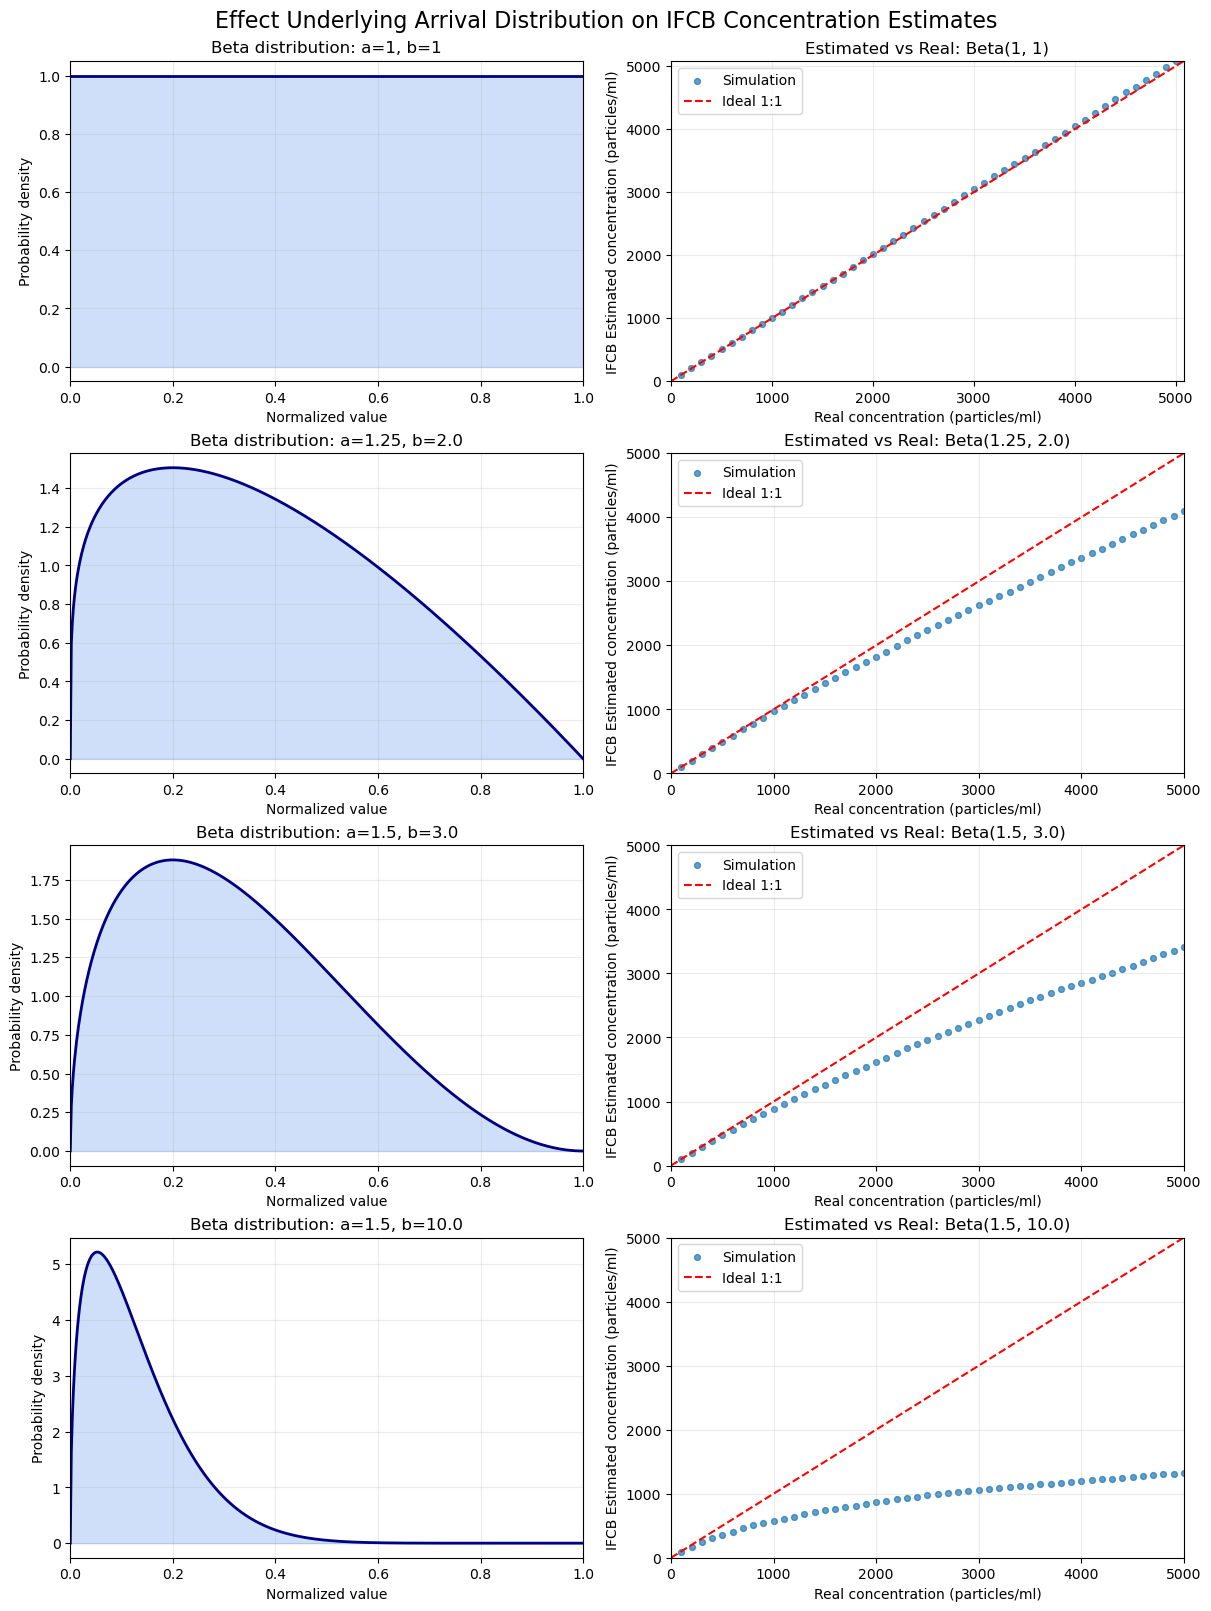

In [31]:
fig, axes = plt.subplots(
    nrows=len(beta_sets),
    ncols=2,
    figsize=(12, 16),
    constrained_layout=True
)

x_beta = np.linspace(0, 1, 500)

for row, (beta_a, beta_b) in enumerate(beta_sets):
    ax_distribution = axes[row, 0]
    ax_concentration = axes[row, 1]

    # Beta distribution
    pdf = beta_dist.pdf(x_beta, beta_a, beta_b)

    ax_distribution.plot(
        x_beta,
        pdf,
        color="navy",
        linewidth=2
    )

    ax_distribution.fill_between(
        x_beta,
        pdf,
        color="cornflowerblue",
        alpha=0.3
    )

    ax_distribution.set_title(
        f"Beta distribution: a={beta_a}, b={beta_b}"
    )
    ax_distribution.set_xlabel("Normalized value")
    ax_distribution.set_ylabel("Probability density")
    ax_distribution.set_xlim(0, 1)
    ax_distribution.grid(alpha=0.25)

    # Run simulation
    summary_df = run_simulation(beta_a, beta_b)

    x = summary_df["target_concentration"]
    y = summary_df["concentration_estimate"]

    # Concentration comparison
    ax_concentration.scatter(
        x,
        y,
        s=18,
        alpha=0.7,
        label="Simulation"
    )

    max_value = max(x.max(), y.max())

    ax_concentration.plot(
        [0, max_value],
        [0, max_value],
        color="red",
        linestyle="--",
        label="Ideal 1:1"
    )

    ax_concentration.set_title(
        f"Estimated vs Real: Beta({beta_a}, {beta_b})"
    )
    ax_concentration.set_xlabel(
        "Real concentration (particles/ml)"
    )
    ax_concentration.set_ylabel(
        "IFCB Estimated concentration (particles/ml)"
    )
    ax_concentration.set_xlim(0, max_value)
    ax_concentration.set_ylim(0, max_value)
    ax_concentration.grid(alpha=0.25)
    ax_concentration.legend()

fig.suptitle(
    "Effect Underlying Arrival Distribution on IFCB Concentration Estimates",
    fontsize=16
)

plt.show()

In [48]:
test_df = simulate_skewed_particles(
    mean_particles=10000,
    run_duration=1200,
    beta_a=1,
    beta_b=1.1,
    seed=1
)

In [40]:
test_df.head()
test_df.describe()

,arrival_time,runtime_fraction
count,10003.000000,10003.000000
mean,398.260400,0.331884
std,240.894031,0.200745
min,0.052892,0.000044
25%,206.152784,0.171794
50%,364.925565,0.304105
75%,563.130391,0.469275
max,1166.983264,0.972486


In [46]:
sampled_df = simulate_ifcb_sampling(
    test_df["arrival_time"],
    inhibit_time=0.08
)

In [42]:


sampled_df.describe()

,arrival_time,inhibit_time,total_inhibit_time,VolumeAnalyzed,Concentration
count,10003.000000,10003.000000,10003.000000,10003.000000,10003.000000
mean,398.260400,0.041931,194.785996,0.847810,2794.916918
std,240.894031,0.039955,113.833587,0.537835,503.208927
min,0.052892,0.000000,0.080000,-0.000113,-8853.436256
25%,206.152784,0.000000,98.640000,0.447990,2578.657858
50%,364.925565,0.080000,187.680000,0.738405,2995.922559
75%,563.130391,0.080000,287.360000,1.149043,3165.793809
max,1166.983264,0.080000,419.440000,3.114764,3237.105844


Text(0, 0.5, 'Estimated concentration (particles/ml)')

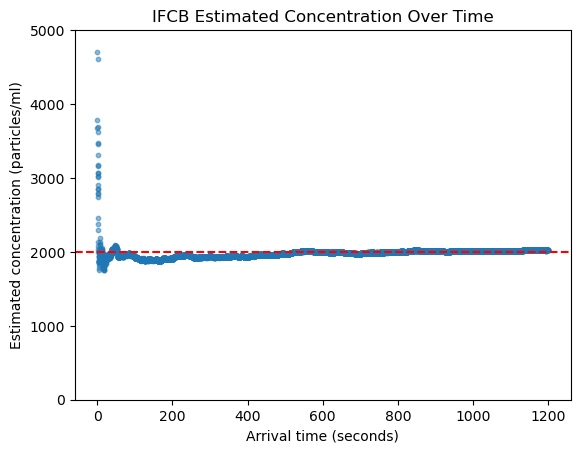

In [47]:
plt.scatter(
    sampled_df["arrival_time"],
    sampled_df["Concentration"],
    s=10,
    alpha=0.5
)
plt.ylim(0, 5000)
plt.axhline(y=len(sampled_df["sampled"])/5, color="red", linestyle="--", label="True concentration")
plt.title("IFCB Estimated Concentration Over Time")
plt.xlabel("Arrival time (seconds)")
plt.ylabel("Estimated concentration (particles/ml)")

In [49]:
alpha = 0.5
beta = 1.1

Text(0, 0.5, 'Estimated concentration (particles/ml)')

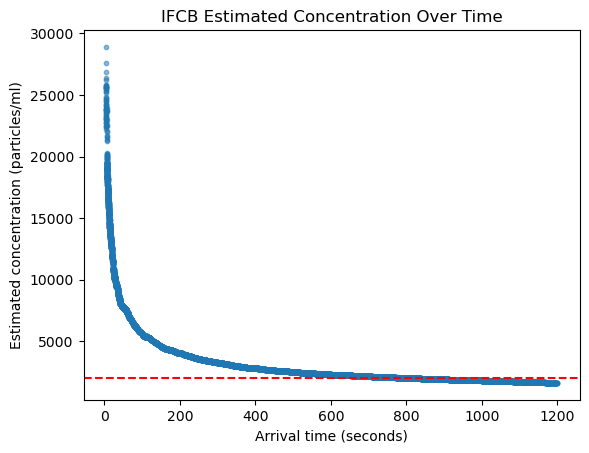

In [59]:
test_df = simulate_skewed_particles(
    mean_particles=10000,
    run_duration=1200,
    beta_a=alpha,
    beta_b=beta,
    seed=1
)

sampled_df = simulate_ifcb_sampling(
    test_df["arrival_time"],
    inhibit_time=0.08
)

plotting_df = sampled_df[sampled_df["arrival_time"]>5]

plt.scatter(
    plotting_df["arrival_time"],
    plotting_df["Concentration"],
    s=10,
    alpha=0.5
)
plt.axhline(y=len(sampled_df["sampled"])/5, color="red", linestyle="--", label="True concentration")
plt.title("IFCB Estimated Concentration Over Time")
plt.xlabel("Arrival time (seconds)")
plt.ylabel("Estimated concentration (particles/ml)")


In [54]:
sampled_df.head()

,arrival_time,sampled,inhibit_time,total_inhibit_time,VolumeAnalyzed,Concentration
1,0.000067,False,0.0,0.08,-0.000333,-3002.522233
2,0.000108,False,0.0,0.08,-0.000333,-3004.066102
3,0.000113,False,0.0,0.08,-0.000333,-3004.262214
4,0.000114,False,0.0,0.08,-0.000333,-3004.282216
5,0.000287,False,0.0,0.08,-0.000332,-3010.803706


In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def simulate_fixed_beta_particles(
    initial_concentration,
    run_duration=1200,
    flow_rate=240,
    beta_a=1,
    beta_b=3,
    seed=None
):
    rng = np.random.default_rng(seed)

    sample_volume = run_duration / flow_rate
    n_particles = round(initial_concentration * sample_volume)

    runtime_fraction = rng.beta(
        beta_a,
        beta_b,
        size=n_particles
    )

    arrival_times = np.sort(runtime_fraction * run_duration)

    return pd.DataFrame({
        "arrival_time": arrival_times,
        "runtime_fraction": np.sort(runtime_fraction)
    })

def plot_beta_concentration_simulations(
    alpha_beta_pairs,
    initial_concentration,
    inhibit_time=0.08,
    run_duration=1200,
    flow_rate=240,
    seed=1
):
    sample_volume = run_duration / flow_rate
    true_concentration = initial_concentration

    n_plots = len(alpha_beta_pairs)

    fig, axes = plt.subplots(
        nrows=n_plots,
        ncols=2,
        figsize=(14, 4 * n_plots),
        squeeze=False
    )

    for row, (alpha, beta) in enumerate(alpha_beta_pairs):
        particles_df = simulate_fixed_beta_particles(
            initial_concentration=initial_concentration,
            run_duration=run_duration,
            flow_rate=flow_rate,
            beta_a=alpha,
            beta_b=beta,
            seed=seed + row
        )

        sampled_df = simulate_ifcb_sampling(
            particles_df["arrival_time"],
            inhibit_time=inhibit_time,
            flow_rate=flow_rate
        )

        beta_ax = axes[row, 0]
        concentration_ax = axes[row, 1]

        # Initial beta-distributed particle arrivals
        beta_ax.hist(
            particles_df["runtime_fraction"],
            bins=40,
            density=True,
            alpha=0.75,
            color="steelblue"
        )

        beta_ax.set_title(
            f"Initial beta distribution: α={alpha}, β={beta}"
        )
        beta_ax.set_xlabel("Runtime fraction")
        beta_ax.set_ylabel("Particle density")

        # IFCB concentration estimate over time
        valid = (
            sampled_df["VolumeAnalyzed"] > 0
        )

        concentration_ax.plot(
            sampled_df.loc[valid, "arrival_time"],
            sampled_df.loc[valid, "Concentration"],
            color="black",
            linewidth=1.5,
            label="IFCB estimate"
        )

        concentration_ax.axhline(
            y=true_concentration,
            color="red",
            linestyle="--",
            label="True initial concentration"
        )

        concentration_ax.set_title(
            f"Concentration estimate: α={alpha}, β={beta}"
        )
        concentration_ax.set_xlabel("Arrival time (seconds)")
        concentration_ax.set_ylabel("Particles/ml")
        concentration_ax.legend()

    plt.tight_layout()
    return fig, axes

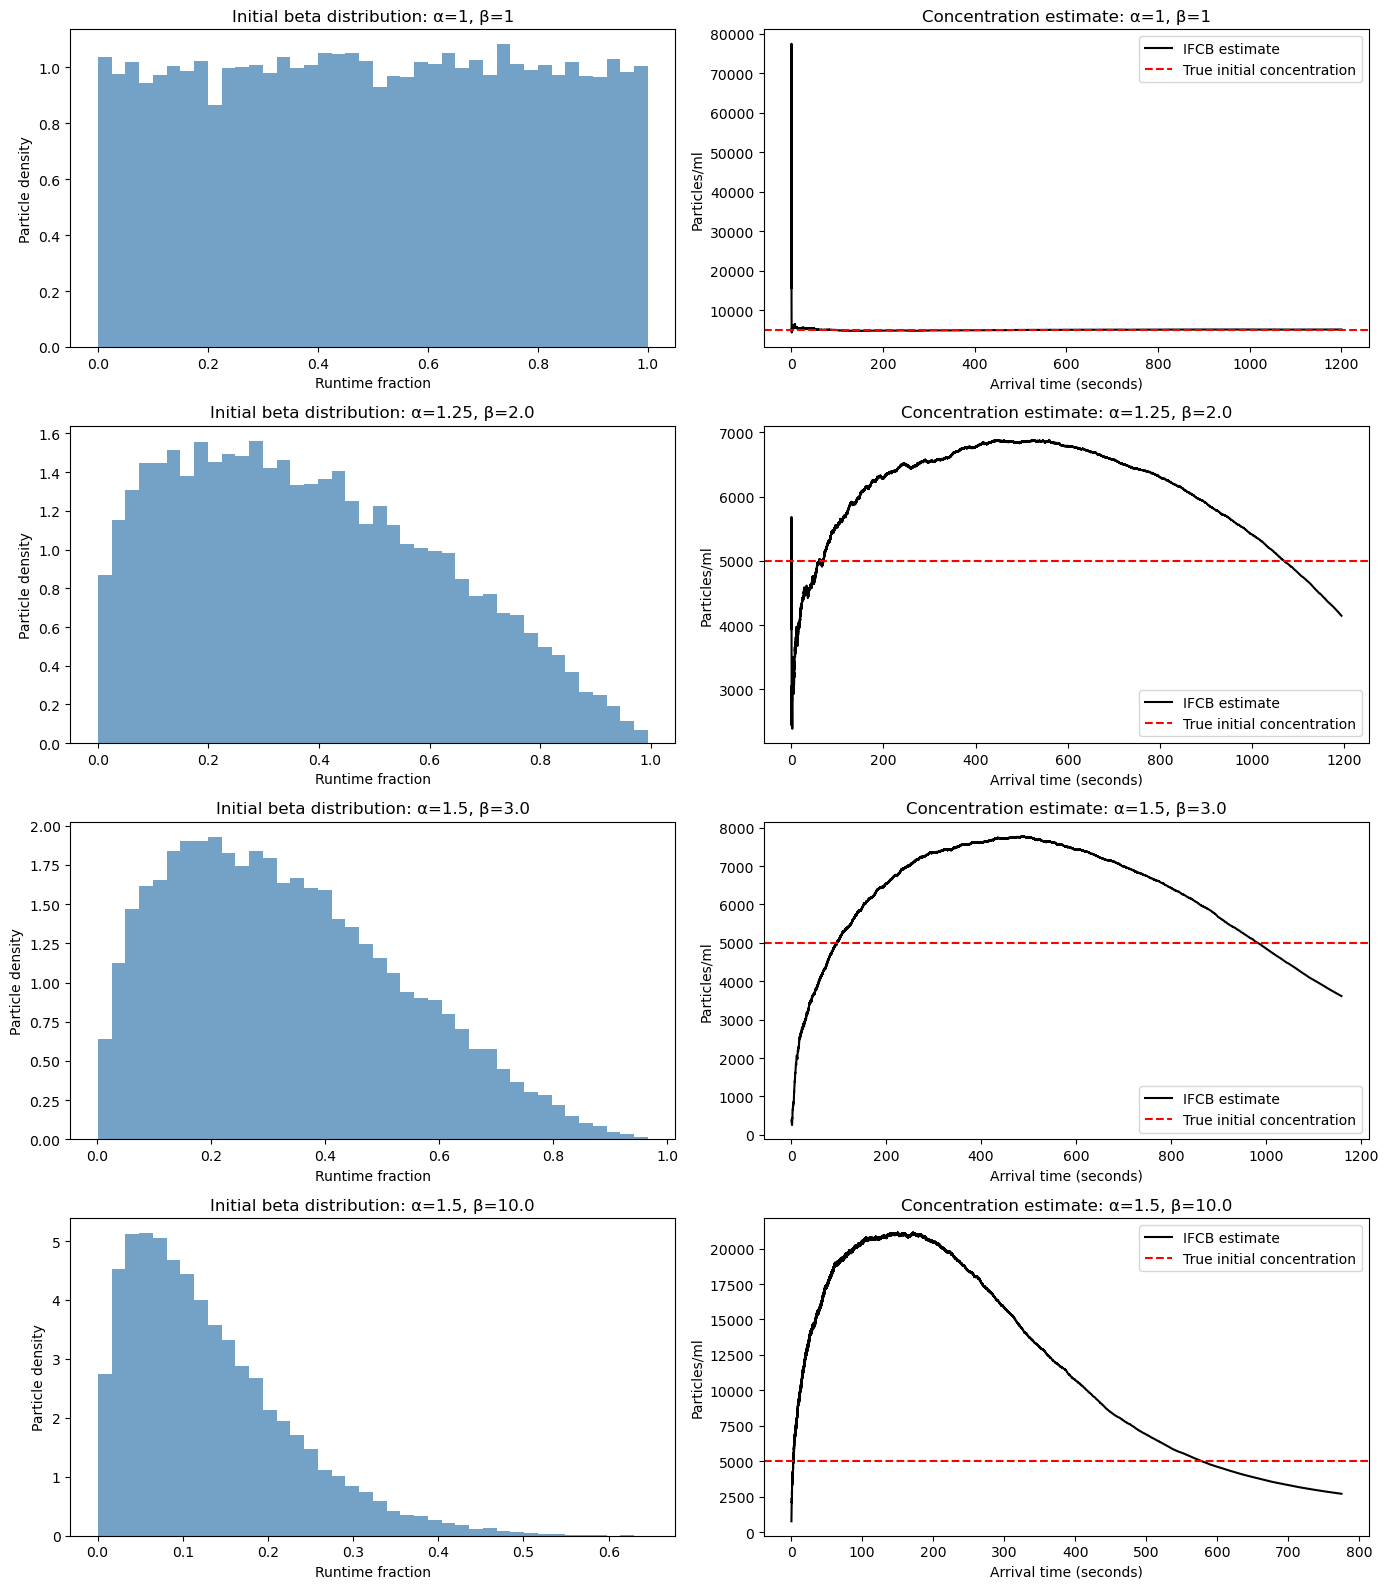

In [64]:
alpha_beta_pairs = [
       (1, 1),
       (1.25, 2.0),
       (1.5, 3.0),
       (1.5, 10.0),
   ]

fig, axes = plot_beta_concentration_simulations(
    alpha_beta_pairs=alpha_beta_pairs,
    initial_concentration=5000,
    inhibit_time=0.08,
    seed=1
)

plt.show()

In [71]:
import numpy as np
import matplotlib.pyplot as plt


def plot_factorial_concentration_grid(
    alpha_beta_pairs,
    concentrations,
    run_duration=1200,
    flow_rate=240,
    inhibit_time=0.08,
    seed=1
):
    concentrations = np.asarray(concentrations)

    n_rows = len(alpha_beta_pairs)
    n_cols = len(concentrations) + 1

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        squeeze=False
    )

    for row, (alpha, beta) in enumerate(alpha_beta_pairs):
        # Use the highest concentration to display the beta distribution
        beta_df = simulate_fixed_beta_particles(
            initial_concentration=concentrations.max(),
            run_duration=run_duration,
            flow_rate=flow_rate,
            beta_a=alpha,
            beta_b=beta,
            seed=seed + row
        )

        # First column: initial beta distribution
        beta_ax = axes[row, 0]

        beta_ax.hist(
            beta_df["runtime_fraction"],
            bins=40,
            density=True,
            color="steelblue",
            alpha=0.75
        )

        beta_ax.set_title(
            f"Beta distribution\nα={alpha}, β={beta}"
        )
        beta_ax.set_xlabel("Runtime fraction")
        beta_ax.set_ylabel("Particle density")
        beta_ax.set_xlim(0, 1)

        # Remaining columns: concentration estimates
        for col, concentration in enumerate(concentrations, start=1):
            particles_df = simulate_fixed_beta_particles(
                initial_concentration=concentration,
                run_duration=run_duration,
                flow_rate=flow_rate,
                beta_a=alpha,
                beta_b=beta,
                seed=seed + row * 1000 + col
            )

            sampled_df = simulate_ifcb_sampling(
                particles_df["arrival_time"],
                inhibit_time=inhibit_time,
                flow_rate=flow_rate
            )

            concentration_ax = axes[row, col]

            valid = sampled_df["arrival_time"] > 5

            concentration_ax.plot(
                sampled_df.loc[valid, "arrival_time"],
                sampled_df.loc[valid, "Concentration"],
                color="black",
                linewidth=1.5,
                label="IFCB estimate"
            )

            concentration_ax.axhline(
                y=concentration,
                color="red",
                linestyle="--",
                label="True concentration"
            )

            concentration_ax.set_title(
                f"{concentration:,.0f} particles/ml"
            )
            concentration_ax.set_xlabel("Arrival time (seconds)")
            concentration_ax.set_ylabel("Particles/ml")
            concentration_ax.legend()
            concentration_ax.set_xlim(0, run_duration)

    fig.suptitle(
        "Factorial Comparison of Beta Distributions and Concentrations",
        fontsize=16
    )

    plt.tight_layout()
    return fig, axes

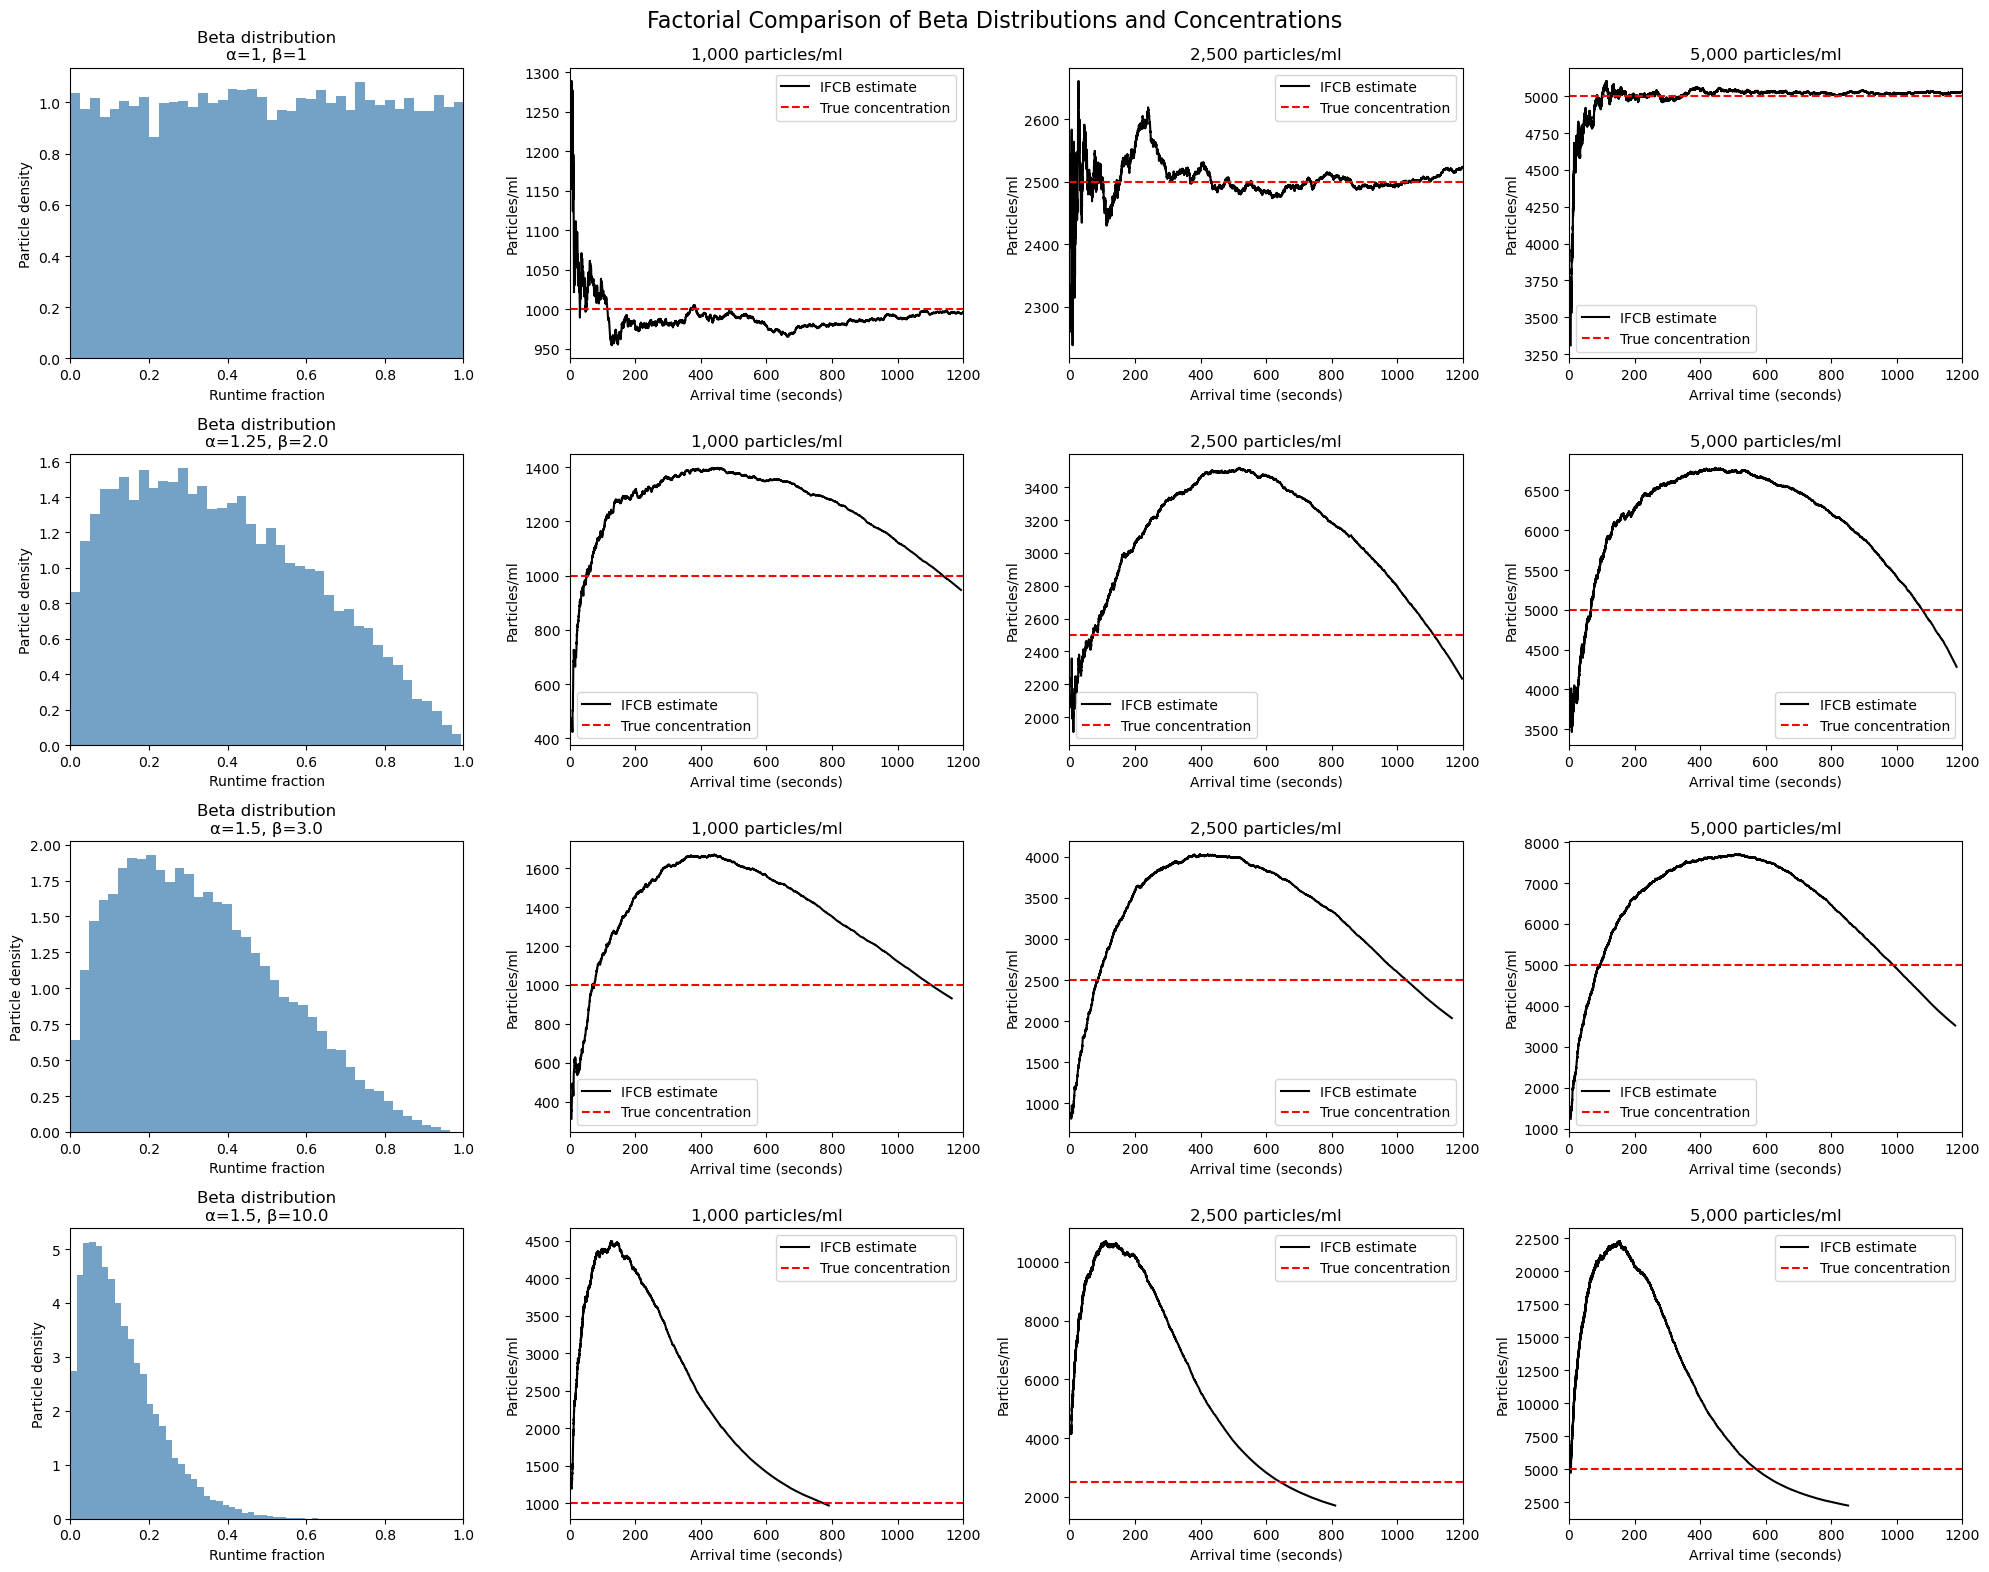

In [72]:
alpha_beta_pairs = [
       (1, 1),
       (1.25, 2.0),
       (1.5, 3.0),
       (1.5, 10.0),
   ]

concentrations = [
    1000,
    2500,
    5000
]

fig, axes = plot_factorial_concentration_grid(
    alpha_beta_pairs=alpha_beta_pairs,
    concentrations=concentrations,
    inhibit_time=0.08,
    seed=1
)

plt.show()